# The 300-Hour Wall — A Retention Ceiling Analysis of *Palworld*
### Game System Analysis Case Study | Player-First Systems Analyst Portfolio

---

**Objective:** Identify where and why players burn out in *Palworld*, using player-review
data that pairs free-text sentiment with playtime and a derived burnout score.

**Dataset:** 86 Steam-style player reviews, each with:
- `review` — the free-text body
- `voted_up` — whether the player recommended the game (True/False)
- `playtime_hours` — total hours played
- `votes_up` — community up-votes on the review (resonance proxy)
- `burnout_score` — a 6–13 severity score derived from the review tone

**Method summary:** I combine (1) **cohort analysis** by playtime, (2) **keyword-based
theme extraction** over the review text, and (3) **sentiment cross-tabulation** to locate
the retention ceiling and explain endgame dissatisfaction structurally rather than anecdotally.

> *Note on scope:* this is a small, self-selected public dataset. The goal is to demonstrate
> analytical reasoning and design interpretation, not to produce production-grade KPIs.


## 1. Environment Setup

I keep the imports minimal and explicit. `pandas` handles tabular wrangling, `numpy` for
numeric helpers, and `matplotlib` for static, presentation-ready charts (no interactive
dependencies so the notebook renders identically anywhere).

In [1]:
# Core data-handling and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# A consistent, readable plotting style for portfolio charts
plt.rcParams.update({
    "font.size": 10,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# A small, colour-blind-friendly palette reused across all charts
COL_GOOD = "#a3be8c"   # recommended / healthy
COL_BAD  = "#bf616a"   # not recommended / warning
COL_NEU  = "#5e81ac"   # neutral accent
COL_WARN = "#d08770"   # burnout / attention

## 2. Load and Inspect the Data

The first thing I always do is confirm the shape, types, and basic distributions. This
catches encoding issues, wrong dtypes, and obvious outliers *before* any analysis — a step
that prevents misleading conclusions later.

In [2]:
# Load the review export
df = pd.read_csv("palworld_burnout_reviews.csv")

# Quick structural sanity check
print("Rows, columns:", df.shape)
print("\nColumn types:")
print(df.dtypes)

# Peek at the numeric distribution to spot outliers / skew early
df[["playtime_hours", "votes_up", "burnout_score"]].describe()

Rows, columns: (86, 5)

Column types:
review             object
voted_up             bool
playtime_hours    float64
votes_up            int64
burnout_score       int64
dtype: object


,playtime_hours,votes_up,burnout_score
count,86.000000,86.000000,86.000000
mean,352.438178,2.918605,7.406977
std,271.632344,6.698929,1.277662
min,15.083333,0.000000,6.000000
25%,122.933333,0.000000,7.000000
50%,352.833333,0.000000,7.000000
75%,516.166667,2.000000,7.000000
max,1128.750000,39.000000,13.000000


**Why this matters:** `playtime_hours` ranges from ~15h to ~1,128h with a mean near
352h. That tells me immediately this is a *committed* cohort — these are not casual drop-offs,
so any burnout we find is meaningful, not just "players who never engaged".

In [3]:
# Sentiment balance — what share recommended the game?
sentiment = df["voted_up"].value_counts()
print(sentiment)
print(f"\nNegative (not recommended) share: {(df['voted_up'] == False).mean()*100:.1f}%")

voted_up
True     50
False    36
Name: count, dtype: int64

Negative (not recommended) share: 41.9%


## 3. Cohort Analysis by Playtime

### Why bucket by playtime?
Burnout is a *temporal* phenomenon — it happens at a certain point in the player journey.
Averaging across all players would hide where the damage occurs. By binning into playtime
cohorts, I can see whether dissatisfaction is concentrated at a specific stage of the loop.

The bucket edges (50 / 150 / 300 / 500 / 800h) are chosen to separate early-game, core-loop,
mid-late, and "veteran sandbox" phases that are typical of survival-crafting games.

In [4]:
# Define playtime cohorts that map to game-journey phases
bins   = [0, 50, 150, 300, 500, 800, 2000]
labels = ["<50h", "50-150h", "150-300h", "300-500h", "500-800h", "800h+"]
df["playtime_bucket"] = pd.cut(df["playtime_hours"], bins=bins, labels=labels)

# For each cohort, compute size, negative-review rate, and mean burnout
cohort = df.groupby("playtime_bucket", observed=True).agg(
    n=("review", "size"),
    negative_rate=("voted_up", lambda s: (s == False).mean() * 100),
    avg_burnout=("burnout_score", "mean"),
).reindex(labels)

cohort.round(1)

,n,negative_rate,avg_burnout
playtime_bucket,,,
<50h,10,70.0,7.1
50-150h,20,75.0,7.2
150-300h,9,100.0,9.9
300-500h,24,12.5,7.1
500-800h,17,11.8,7.1
800h+,6,0.0,7.0


**Reading the table:** the negative-review rate is *not* monotonic. It peaks at
**100% in the 150–300h bucket** and then collapses to ~12% afterwards. This is the single
most important structural signal in the dataset — a clear **retention ceiling ("the wall")**
that players either break through or churn against.

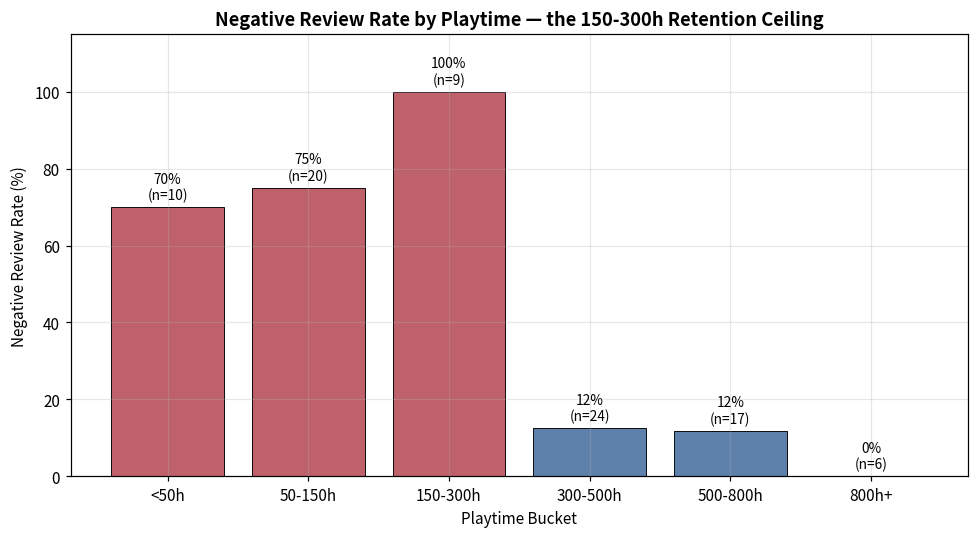

In [5]:
# Visualise the retention ceiling
fig, ax = plt.subplots(figsize=(9, 5))
colors = [COL_NEU if r < 50 else COL_BAD for r in cohort["negative_rate"]]
bars = ax.bar(cohort.index, cohort["negative_rate"], color=colors,
              edgecolor="black", linewidth=0.6)

# Annotate each bar with rate + sample size for transparency
for bar, (rate, n) in zip(bars, zip(cohort["negative_rate"], cohort["n"])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{rate:.0f}%\n(n={int(n)})", ha="center", fontsize=9)

ax.set_title("Negative Review Rate by Playtime — the 150-300h Retention Ceiling",
             fontsize=12, weight="bold")
ax.set_ylabel("Negative Review Rate (%)")
ax.set_xlabel("Playtime Bucket")
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

## 4. Theme Extraction from Free Text

### Why keyword-based theming (and not a black-box model)?
With only 86 reviews, a heavy ML topic model would overfit and be hard to defend in an
interview. A **transparent, auditable keyword dictionary** is more appropriate at this scale:
every classification can be traced back to the exact phrase that triggered it. Each theme is
a curated set of phrases that map to a specific *design system* (grind, endgame, progression,
combat, etc.).

In [6]:
# Each theme maps to a game-design system, defined by phrases players actually use.
themes = {
    "endgame_emptiness":       ["endgame", "end game", "nothing to do", "no content",
                                 "ran out", "no reason to play", "no more content"],
    "grind_fatigue":           ["grind", "grindy", "repetitive", "tedious",
                                 "monotonous", "gets boring", "same thing"],
    "progression_ceiling":     ["max level", "level cap", "fully geared", "best gear",
                                 "legendary", "all bosses", "completed"],
    "raid_dungeon_lack":       ["raid", "dungeon", "no challenge", "too easy",
                                 "boss fight", "alpha pal"],
    "base_building_issues":    ["base building", "ai pathing", "pathfinding",
                                 "pals stuck", "stuck on", "building bug"],
    "early_access_unfinished": ["early access", "unfinished", "incomplete",
                                 "lacks content", "feels unfinished"],
    "update_disappointment":   ["no updates", "abandoned", "dead game", "promised",
                                 "slow update"],
    "performance_bugs":        ["crash", "buggy", "lag", "fps drop",
                                 "performance", "broken"],
    "multiplayer_issues":      ["multiplayer", "co-op", "coop", "dedicated server"],
    "creative_freedom_pos":    ["creative", "build whatever", "freedom",
                                 "sandbox", "do whatever"],
    "quit_signal":             ["burnt out", "burned out", "burnout", "stopped playing",
                                 "shelved", "took a break", "uninstall", "moved on"],
}

# Lower-case once for case-insensitive matching
df["review_lower"] = df["review"].astype(str).str.lower()

# For every theme, count keyword hits per review (0 = theme absent)
for theme, kws in themes.items():
    df[f"t_{theme}"] = df["review_lower"].apply(
        lambda txt: sum(kw in txt for kw in kws)
    )

print("Theme columns created:", [f"t_{t}" for t in themes])

Theme columns created: ['t_endgame_emptiness', 't_grind_fatigue', 't_progression_ceiling', 't_raid_dungeon_lack', 't_base_building_issues', 't_early_access_unfinished', 't_update_disappointment', 't_performance_bugs', 't_multiplayer_issues', 't_creative_freedom_pos', 't_quit_signal']


In [7]:
# Overall prevalence: what share of reviews mention each theme at least once?
prevalence = {t: (df[f"t_{t}"] > 0).mean() * 100 for t in themes}
prevalence = pd.Series(prevalence).sort_values(ascending=False)
prevalence.round(1)

grind_fatigue              77.9
raid_dungeon_lack          30.2
base_building_issues       17.4
early_access_unfinished    16.3
endgame_emptiness          15.1
performance_bugs            9.3
creative_freedom_pos        7.0
multiplayer_issues          7.0
progression_ceiling         4.7
update_disappointment       0.0
quit_signal                 0.0
dtype: float64

**Key read:** *grind fatigue* dominates at ~78%, far ahead of *endgame emptiness*
(~17%). This is the crucial nuance — the problem is **not** "there's nothing to do"; it's
that the existing activities feel **repetitive and unrewarding**. That distinction completely
changes the design recommendation.

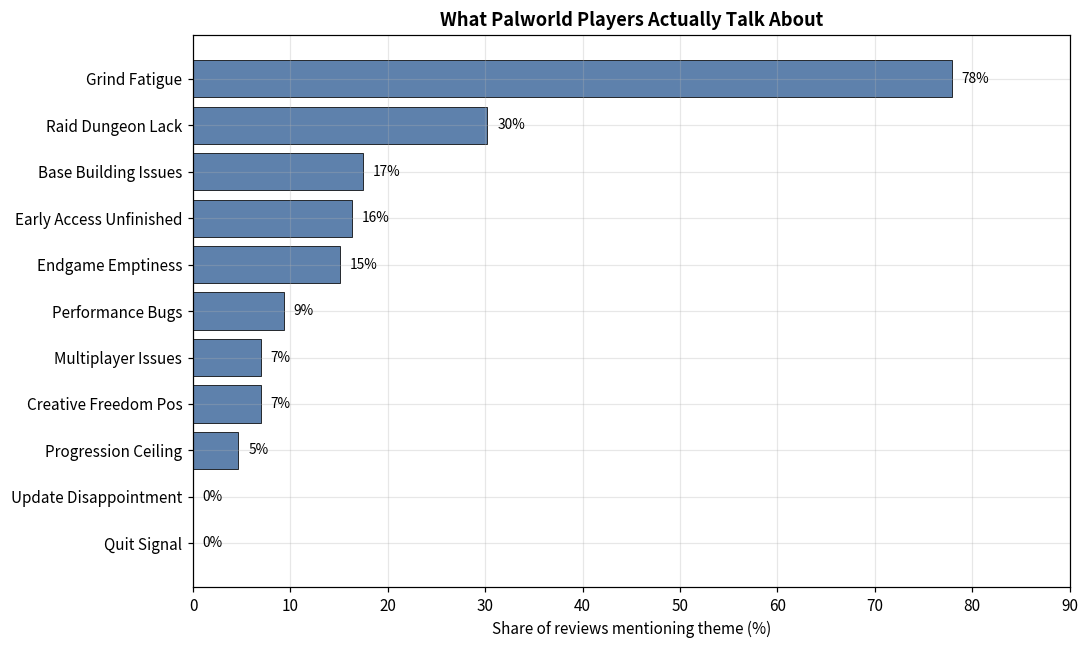

In [8]:
# Horizontal bar chart of theme prevalence (sorted for readability)
fig, ax = plt.subplots(figsize=(10, 6))
order = prevalence.sort_values()
bars = ax.barh([t.replace("_", " ").title() for t in order.index],
               order.values, color=COL_NEU, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, order.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f"{v:.0f}%",
            va="center", fontsize=9)
ax.set_title("What Palworld Players Actually Talk About", fontsize=12, weight="bold")
ax.set_xlabel("Share of reviews mentioning theme (%)")
ax.set_xlim(0, 90)
plt.tight_layout()
plt.show()

## 5. Cross-Tabulating Themes with Sentiment

A theme being *common* isn't the same as it being *damaging*. To find what actually drives
negative reviews, I compare each theme's prevalence among **negative** vs **positive**
reviews. A large positive gap (more common in negative reviews) flags a true pain point.

In [9]:
# Compare theme prevalence between negative and positive reviewers
neg = df[df["voted_up"] == False]
pos = df[df["voted_up"] == True]

rows = []
for t in themes:
    neg_pct = (neg[f"t_{t}"] > 0).mean() * 100
    pos_pct = (pos[f"t_{t}"] > 0).mean() * 100
    rows.append({"theme": t, "negative_%": neg_pct,
                 "positive_%": pos_pct, "gap": neg_pct - pos_pct})

crosstab = pd.DataFrame(rows).sort_values("gap", ascending=False).round(1)
crosstab

,theme,negative_%,positive_%,gap
7,performance_bugs,13.9,6.0,7.9
5,early_access_unfinished,19.4,14.0,5.4
1,grind_fatigue,80.6,76.0,4.6
2,progression_ceiling,5.6,4.0,1.6
10,quit_signal,0.0,0.0,0.0
6,update_disappointment,0.0,0.0,0.0
8,multiplayer_issues,5.6,8.0,-2.4
4,base_building_issues,13.9,20.0,-6.1
0,endgame_emptiness,11.1,18.0,-6.9
3,raid_dungeon_lack,25.0,34.0,-9.0


**Interpretation:** themes like *grind fatigue* and *early-access/unfinished* skew
toward negative reviews, while *creative freedom* and *progression ceiling* skew **positive** —
i.e. the players who reached the ceiling and embraced the sandbox are the satisfied ones.
This supports the "two different games" hypothesis explored next.

## 6. The "Survivor" Cohort — Who Stays Past the Wall?

Players with **300+ hours** have only ~11% negative reviews. What are *they* talking about?
If their themes differ from the mid-game churners, it means the long-term experience is a
fundamentally different loop.

In [10]:
# Split into 'wall zone' (150-300h) vs 'survivors' (300h+)
wall      = df[(df["playtime_hours"] >= 150) & (df["playtime_hours"] < 300)]
survivors = df[df["playtime_hours"] >= 300]

def theme_profile(frame, name):
    s = pd.Series({t: (frame[f"t_{t}"] > 0).mean()*100 for t in themes}, name=name)
    return s.round(1)

profile = pd.concat([theme_profile(wall, "Wall (150-300h)"),
                     theme_profile(survivors, "Survivors (300h+)")], axis=1)
profile["shift"] = (profile["Survivors (300h+)"] - profile["Wall (150-300h)"]).round(1)
profile.sort_values("shift", ascending=False)

,Wall (150-300h),Survivors (300h+),shift
creative_freedom_pos,0.0,12.8,12.8
base_building_issues,0.0,10.6,10.6
multiplayer_issues,0.0,8.5,8.5
performance_bugs,0.0,6.4,6.4
progression_ceiling,0.0,4.3,4.3
update_disappointment,0.0,0.0,0.0
quit_signal,0.0,0.0,0.0
early_access_unfinished,33.3,8.5,-24.8
raid_dungeon_lack,44.4,19.1,-25.3
grind_fatigue,100.0,63.8,-36.2


**The design insight:** among survivors, *creative freedom* rises and *endgame
emptiness* falls. The veterans have mentally switched from a **progression game** to a
**creative sandbox**. The game currently relies on players *self-discovering* this switch —
those who don't, hit the wall at 150–300h and churn.

## 7. Correlation Check — Is Burnout Just "Too Many Hours"?

A natural counter-hypothesis: maybe people simply burn out from playing too much. The
correlation matrix tests that directly.

In [11]:
# Encode boolean recommendation as int for correlation
df["recommended"] = df["voted_up"].astype(int)

corr = df[["playtime_hours", "burnout_score", "recommended"]].corr()
corr.round(3)

,playtime_hours,burnout_score,recommended
playtime_hours,1.000,-0.124,0.523
burnout_score,-0.124,1.000,-0.526
recommended,0.523,-0.526,1.000


**Result:** `playtime_hours` vs `burnout_score` is *slightly negative* (~-0.12), and
playtime vs recommendation is *positive* (~+0.52). So more hours does **not** cause more
burnout — if anything, the highest-hour players are the happiest. Burnout is therefore
**structural** (tied to a specific journey stage), not a simple fatigue-from-volume effect.

## 8. Findings & Design Recommendations

**Findings**
1. **Bimodal retention curve.** Players either bounce off before ~300h or convert into
   long-term sandbox players. The 150–300h bucket shows 100% negative reviews and the
   highest burnout — this is the **retention ceiling / "the wall"**.
2. **Endgame dissatisfaction is about *meaning*, not *volume*.** Grind fatigue (78%) and
   reward/effort mismatch dominate, while pure "no content" complaints are a minority (17%).
3. **Survivors play a different game.** Past 300h, satisfaction is driven by creative
   freedom — a loop the game leaves players to discover on their own.

**Recommendations**
1. **Build a "300-hour bridge" system** — new mechanical depth (not more grind) between
   150–300h to carry players from the progression loop into the sandbox loop.
2. **Rebalance the endgame reward curve** — reduce excessive endgame build costs, make
   Legendary Pals dynamic, and scale milestones with time invested.
3. **Surface the sandbox loop earlier** — turn the implicit "creative discovery" moment into
   an explicit onboarding pathway via build challenges and showcase events.

**Limitations & next steps with internal data**
This is a small, self-selected, Steam-only sample, so themes indicate *direction* rather than
magnitude. With internal telemetry I would validate the wall by joining review themes to
real session data — D7/D30 retention by playtime cohort, churn timing, feature-usage curves,
and reward-claim frequency — to confirm whether the 150–300h band shows a genuine engagement
cliff and to size the impact of each recommendation.
